In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("accidents_weather_ca_merged.csv")

df.head()

,Start_Lat,Start_Lng,Start_Time,Severity,lat,lon,weather_main,weather_desc,temp_f,humidity,visibility,wind_speed,rain_1h
0,38.362831,-122.267197,2016-12-09 05:25:36,2,38.362831,-122.267197,Clear,clear sky,60.03,77,10000,6.91,0
1,34.022625,-118.156616,2016-07-12 10:55:04,2,34.022625,-118.156616,Clear,clear sky,65.93,40,10000,4.61,0
2,38.254620,-122.335907,2016-06-06 11:20:16,2,38.254620,-122.335907,Clear,clear sky,60.04,76,10000,6.91,0
3,38.003071,-121.337051,2016-12-17 09:25:08,2,38.003071,-121.337051,Clear,clear sky,58.32,78,10000,9.22,0
4,37.403236,-122.046913,2016-11-04 11:01:44,2,37.403236,-122.046913,Clear,clear sky,60.51,72,10000,8.05,0


In [3]:
# Drop duplicate columns
df = df.drop(columns=['Start_Lat', 'Start_Lng'], errors='ignore')

# Drop unusable time column
df = df.drop(columns=['Start_Time'], errors='ignore')

# Check missing values
df = df.dropna()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Severity      500 non-null    int64  
 1   lat           500 non-null    float64
 2   lon           500 non-null    float64
 3   weather_main  500 non-null    object 
 4   weather_desc  500 non-null    object 
 5   temp_f        500 non-null    float64
 6   humidity      500 non-null    int64  
 7   visibility    500 non-null    int64  
 8   wind_speed    500 non-null    float64
 9   rain_1h       500 non-null    int64  
dtypes: float64(4), int64(4), object(2)
memory usage: 39.2+ KB


In [5]:
categorical_cols = df.select_dtypes(include=['object']).columns

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

df.head()

,Severity,lat,lon,temp_f,humidity,visibility,wind_speed,rain_1h,weather_main_Clouds,weather_main_Smoke,weather_desc_clear sky,weather_desc_few clouds,weather_desc_overcast clouds,weather_desc_scattered clouds,weather_desc_smoke
0,2,38.362831,-122.267197,60.03,77,10000,6.91,0,False,False,True,False,False,False,False
1,2,34.022625,-118.156616,65.93,40,10000,4.61,0,False,False,True,False,False,False,False
2,2,38.254620,-122.335907,60.04,76,10000,6.91,0,False,False,True,False,False,False,False
3,2,38.003071,-121.337051,58.32,78,10000,9.22,0,False,False,True,False,False,False,False
4,2,37.403236,-122.046913,60.51,72,10000,8.05,0,False,False,True,False,False,False,False


In [6]:
X = df.drop(columns=['Severity'])
y = df['Severity']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (400, 14)
Testing set size: (100, 14)


In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
svm_linear = SVC(kernel='linear', C=1)
svm_linear.fit(X_train_scaled, y_train)

y_pred_linear = svm_linear.predict(X_test_scaled)

acc_linear = accuracy_score(y_test, y_pred_linear)
print("Linear Kernel Accuracy:", acc_linear)

Linear Kernel Accuracy: 0.71


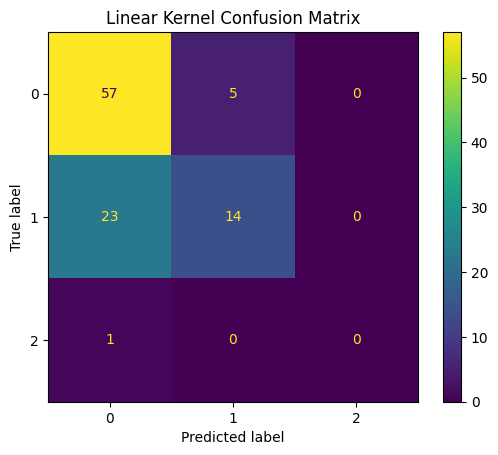

In [10]:
cm_linear = confusion_matrix(y_test, y_pred_linear)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_linear)
disp.plot()

plt.title("Linear Kernel Confusion Matrix")
plt.show()

In [11]:
svm_poly = SVC(kernel='poly', degree=3, C=1)
svm_poly.fit(X_train_scaled, y_train)

y_pred_poly = svm_poly.predict(X_test_scaled)

acc_poly = accuracy_score(y_test, y_pred_poly)
print("Polynomial Kernel Accuracy:", acc_poly)

Polynomial Kernel Accuracy: 0.67


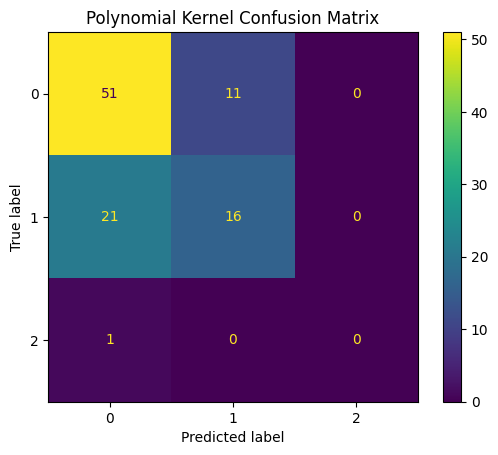

In [12]:
cm_poly = confusion_matrix(y_test, y_pred_poly)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_poly)
disp.plot()

plt.title("Polynomial Kernel Confusion Matrix")
plt.show()

In [13]:
svm_rbf = SVC(kernel='rbf', C=1)
svm_rbf.fit(X_train_scaled, y_train)

y_pred_rbf = svm_rbf.predict(X_test_scaled)

acc_rbf = accuracy_score(y_test, y_pred_rbf)
print("RBF Kernel Accuracy:", acc_rbf)

RBF Kernel Accuracy: 0.67


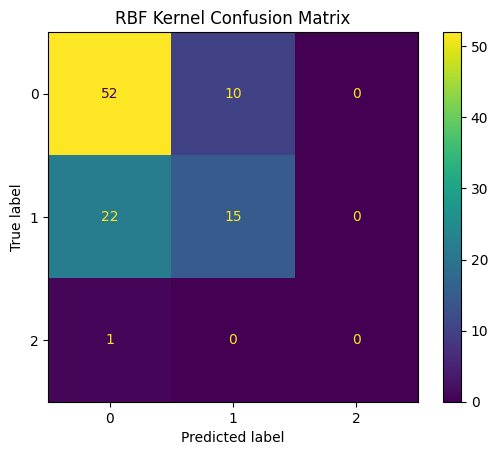

In [14]:
cm_rbf = confusion_matrix(y_test, y_pred_rbf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rbf)
disp.plot()

plt.title("RBF Kernel Confusion Matrix")
plt.show()

In [15]:
costs = [0.01, 0.1, 1, 10]

for c in costs:
    model = SVC(kernel='rbf', C=c)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    print(f"RBF Kernel with C={c}: Accuracy = {acc}")

RBF Kernel with C=0.01: Accuracy = 0.62
RBF Kernel with C=0.1: Accuracy = 0.62
RBF Kernel with C=1: Accuracy = 0.67
RBF Kernel with C=10: Accuracy = 0.67
